# Lecture 6 — Linear Regression

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Loading Dataset

In [2]:
data = pd.read_csv("datasets/lecture6_salaryData.csv")
data.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


Dataset Shape

In [3]:
data.shape

(40, 2)

Checking Null Values

In [4]:
data.isnull().sum()

Experience Years    0
Salary              0
dtype: int64

Information About Data

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 768.0 bytes


Statistical Information

In [6]:
data.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


Separating Features And Target Value

In [12]:
X = data[["Experience Years"]]
y = data["Salary"]

Spliting Data Into Training And Testing Data

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Checking Training Data

In [14]:
X_train
X_test
y_train
y_test

19     61111
16     56957
15     55794
26     93940
4      43525
12     57189
37    112635
27     91000
Name: Salary, dtype: int64

Training Linear Regression Model

In [15]:
model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Checking Model Parameters

In [ ]:
model.coef_  #slope [m]

array([9408.03127251])

In [17]:
model.intercept_ #intercept [b]

np.float64(26716.250176145535)

Predictions From The Model

In [23]:
y_pred = model.predict(X_test)
y_pred

array([ 69052.39090243,  64348.37526617,  64348.37526617,  83164.43781119,
        45532.31272116,  61525.96588442, 117033.35039221,  85046.04406569])

Now Comparing Predictions

In [24]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
19,61111,69052.390902
16,56957,64348.375266
15,55794,64348.375266
26,93940,83164.437811
4,43525,45532.312721


Visualizing Regression Line

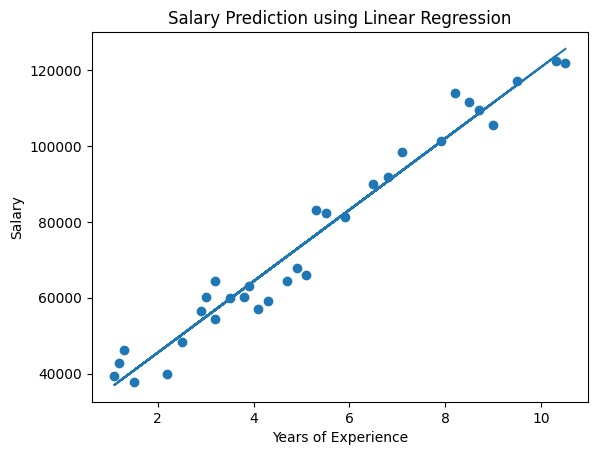

In [25]:
plt.scatter(X_train, y_train)

plt.plot(X_train, model.predict(X_train))

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")

plt.show()

Visualizing Test

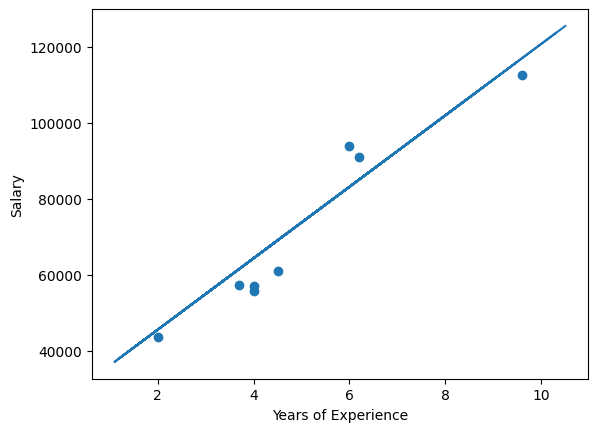

In [26]:
plt.scatter(X_test, y_test)

plt.plot(X_train, model.predict(X_train))

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

Predicting For Any Random Value

In [29]:
model.predict([[10]])

c:\Users\asus2\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([120796.56290121])

Saving The Model

In [30]:
import joblib

joblib.dump(model, "salary_model.pkl")

['salary_model.pkl']

Loading The Model

In [31]:
loaded_model = joblib.load("salary_model.pkl")

loaded_model.predict([[7]])

c:\Users\asus2\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92572.46908369])